In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy import stats

In [2]:
# Dataset with outliers
np.random.seed(42)
df = pd.DataFrame({
    'value': np.concatenate([
        np.random.normal(100, 15, 200),
        [200, 210, 220, 5, -10, 250]
    ])
})
df.head()

,value
0,107.450712
1,97.926035
2,109.715328
3,122.845448
4,96.487699


In [4]:
df.describe()

,value
count,206.000000
mean,100.741200
std,24.082802
min,-10.000000
25%,89.330847
50%,100.135865
75%,108.061081
max,250.000000


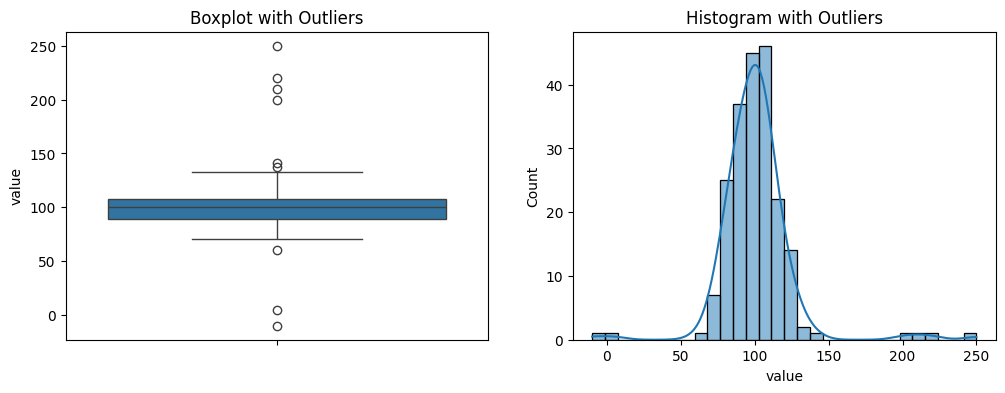

In [3]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['value'])
plt.title("Boxplot with Outliers")

plt.subplot(1, 2, 2)
sns.histplot(df['value'], bins=30, kde=True)
plt.title("Histogram with Outliers")
plt.show()

In [25]:
z_scores             = np.abs(stats.zscore(df['value']))
df['z_outlier']      = z_scores > 3

In [22]:
q1                   = df['value'].quantile(0.25)
q3                   = df['value'].quantile(0.75)
IQR                  = q3 - q1
lower_bound          = q1 - 1.5 * IQR
upper_bound          = q3 + 1.5 * IQR

df['iqr_outlier']    = (df['value'] < lower_bound) | (df['value'] > upper_bound)

In [26]:
print(df.tail(10))

          value  iqr_outlier  z_outlier
196   86.742138        False      False
197  102.305877        False      False
198  100.873131        False      False
199   82.855446        False      False
200  200.000000         True       True
201  210.000000         True       True
202  220.000000         True       True
203    5.000000         True       True
204  -10.000000         True       True
205  250.000000         True       True


In [31]:
df_capped = df.copy()
# iqr method to removed
df_removed = df[~df['iqr_outlier']]

# capped the outliear(winzorization)
df_capped['value'] = np.where(df_capped['value'] > upper_bound,upper_bound,
                             np.where(df_capped['value'] < lower_bound, lower_bound,df_capped['value']))

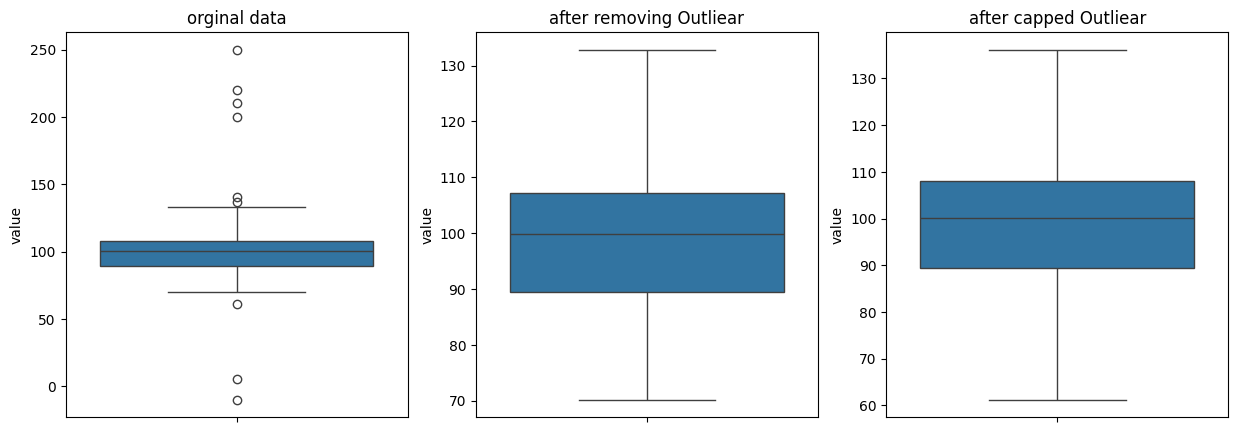

In [33]:
fig, axes = plt.subplots(1,3,figsize = (15,5))
sns.boxplot(y = df['value'], ax=axes[0])
axes[0].set_title("orginal data")

sns.boxplot(y = df_removed['value'], ax = axes[1])
axes[1].set_title("after removing Outliear")

sns.boxplot(y = df_capped['value'], ax = axes[2])
axes[2].set_title("after capped Outliear")

plt.show()